In [1178]:
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from random import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your InfluxDB token, organization, and bucket
org = "ur3e"
bucket = "ur3e"
token = "SECRET_AF"

# Initialize the client
client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
write_api = client.write_api(write_options=SYNCHRONOUS)   
query_api = client.query_api()

In [1179]:
time_start = "-30m"
time_stop = "now()"
window = "1s"

query_sensor_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "sensor_data")
  |> filter(fn: (r) => r["_field"] =~ /q_actual_joint_0/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

query_model_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "dt_model_Data")
  |> filter(fn: (r) => r["_field"] =~ /q_actual_joint_0/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

df_sensor_data = query_api.query_data_frame(query_sensor_data)
df_model_data = query_api.query_data_frame(query_model_data)

# estimate std for sensor data
std_sensor = df_sensor_data['q_actual_joint_0'].std()
print(f"Estimated standard deviation for sensor data: {std_sensor}")



Estimated standard deviation for sensor data: 6.310483282548284e-06


In [1180]:
print(df_sensor_data.head())

    result  table                           _start  \
0  _result      0 2026-04-21 08:33:57.851946+00:00   
1  _result      0 2026-04-21 08:33:57.851946+00:00   
2  _result      0 2026-04-21 08:33:57.851946+00:00   
3  _result      0 2026-04-21 08:33:57.851946+00:00   
4  _result      0 2026-04-21 08:33:57.851946+00:00   

                             _stop                            _time  \
0 2026-04-21 09:03:57.851946+00:00 2026-04-21 08:55:59.053520+00:00   
1 2026-04-21 09:03:57.851946+00:00 2026-04-21 08:55:59.107044+00:00   
2 2026-04-21 09:03:57.851946+00:00 2026-04-21 08:55:59.159296+00:00   
3 2026-04-21 09:03:57.851946+00:00 2026-04-21 08:55:59.209861+00:00   
4 2026-04-21 09:03:57.851946+00:00 2026-04-21 08:55:59.262658+00:00   

  _measurement     source  q_actual_joint_0  
0  sensor_data  pt_mockup      6.064021e-08  
1  sensor_data  pt_mockup      2.684961e-08  
2  sensor_data  pt_mockup      1.343359e-07  
3  sensor_data  pt_mockup      1.588705e-07  
4  sensor_data  pt

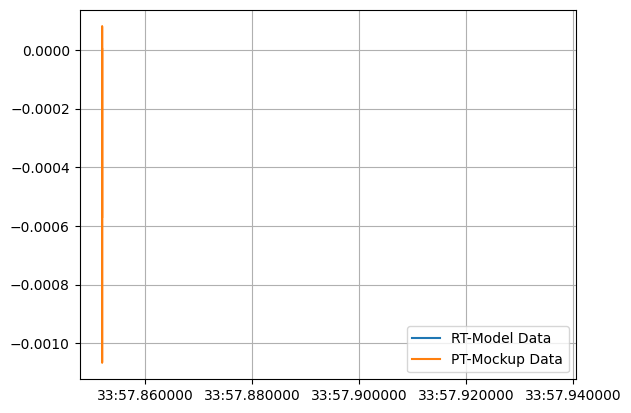

In [1181]:
sensor_data_np = df_sensor_data.to_numpy()
model_data_np = df_model_data.to_numpy()

joint_0_q_sensor = sensor_data_np[:, -1]
timestamp_sensor = sensor_data_np[:, 2]

joint_0_q_model = model_data_np[:, -1]
timestamp_model = model_data_np[:, 2]

# Convert to degrees
def rad2deg(x):
    return 180*x/np.pi
joint_0_q_sensor = rad2deg(joint_0_q_sensor)
joint_0_q_model = rad2deg(joint_0_q_model)

plt.plot(timestamp_model, joint_0_q_model, '-', label="RT-Model Data")
plt.plot(timestamp_sensor, joint_0_q_sensor, '-', label="PT-Mockup Data")
plt.legend()
plt.grid()


4.779353333344295e-10

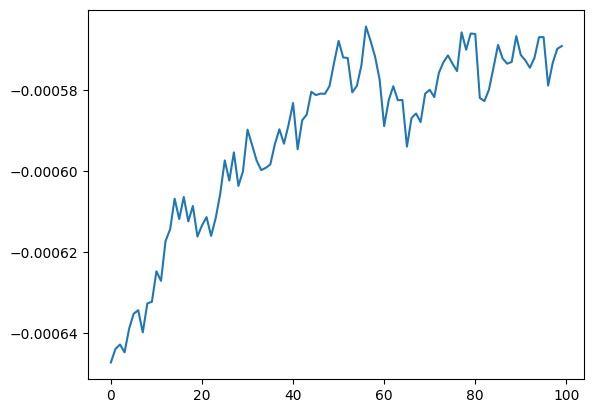

In [1182]:
diff = joint_0_q_sensor

plt.plot(diff[-100:], '-', label="RT-Model Data")
np.var(diff[-100:]).item()